# Cross-Platform Ads Performance: Google vs. Meta vs. TikTok

**Business question:** Across Google, Meta and TikTok ads in 2024, which platforms and campaign types return the most revenue per dollar, where should budget move, and which weeks need attention?

**Data:** [Global Ads Performance (Kaggle)](https://www.kaggle.com/datasets/nudratabbas/global-ads-performance-google-meta-tiktok): 1,800 campaign-day records, Jan–Dec 2024, across 3 platforms, 4 campaign types, 5 industries and 7 countries. **The dataset is simulated** (per its Kaggle description), with realistic relationships between impressions, clicks, spend, conversions and revenue. Findings show the analysis method, not real market results.

| Metric | Formula |
|---|---|
| CTR | clicks ÷ impressions |
| CPC | spend ÷ clicks |
| CPM | spend ÷ impressions × 1,000 |
| CVR | conversions ÷ clicks |
| CPA | spend ÷ conversions |
| **ROAS** | revenue ÷ spend |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ACCENT, MUTED, BAD = '#2E5C8A', '#B8C4CE', '#B4483C'
df = pd.read_csv('global_ads_performance_dataset.csv', parse_dates=['date'])
print(df.shape, df['date'].min().date(), 'to', df['date'].max().date())
df.head()

(1800, 14) 2024-01-01 to 2024-12-30


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


## 1. Data checks

In [2]:
recalc = pd.DataFrame({
    'CTR': (df['clicks'] / df['impressions'] - df['CTR']).abs() > 0.0005,
    'CPC': (df['ad_spend'] / df['clicks'] - df['CPC']).abs() > 0.01,
    'CPA': (df['ad_spend'] / df['conversions'] - df['CPA']).abs() > 0.01,
    'ROAS': (df['revenue'] / df['ad_spend'] - df['ROAS']).abs() > 0.01,
})
checks = pd.Series({
    'Missing values': int(df.isna().sum().sum()),
    'Duplicate rows': int(df.duplicated().sum()),
    'Clicks > impressions': int((df['clicks'] > df['impressions']).sum()),
    'Conversions > clicks': int((df['conversions'] > df['clicks']).sum()),
    'Pre-computed CTR/CPC/CPA/ROAS that do not match raw columns': int(recalc.any(axis=1).sum()),
})
checks.to_frame('count')

,count
Missing values,0
Duplicate rows,0
Clicks > impressions,0
Conversions > clicks,0
Pre-computed CTR/CPC/CPA/ROAS that do not match raw columns,0


All checks pass, so the pre-computed ratio columns are consistent with the raw numbers. They are still **recalculated from totals** below, for the reason shown next.

## 2. A reporting trap: averaging ROAS

In [3]:
true_roas = df['revenue'].sum() / df['ad_spend'].sum()
avg_roas = df['ROAS'].mean()
print(f"Average of row-level ROAS:          {avg_roas:.2f}")
print(f"True ROAS (total revenue / spend):  {true_roas:.2f}")
print(f"Averaging overstates ROAS by {avg_roas / true_roas - 1:.0%}")

Average of row-level ROAS:          6.45
True ROAS (total revenue / spend):  4.88
Averaging overstates ROAS by 32%


A simple average gives every row equal weight, so a small campaign with a lucky ROAS counts as much as a large one. ROAS, CPA and CTR are ratios, so they have to be calculated from **summed** numerators and denominators. Every number in this notebook is calculated that way.

In [4]:
def metrics(g):
    s = g[['impressions', 'clicks', 'ad_spend', 'conversions', 'revenue']].sum()
    return pd.Series({
        'rows': len(g), 'spend': s['ad_spend'], 'revenue': s['revenue'], 'conversions': s['conversions'],
        'CTR': s['clicks'] / s['impressions'], 'CPC': s['ad_spend'] / s['clicks'],
        'CPM': s['ad_spend'] / s['impressions'] * 1000, 'CVR': s['conversions'] / s['clicks'],
        'CPA': s['ad_spend'] / s['conversions'], 'ROAS': s['revenue'] / s['ad_spend'],
        'spend_share': s['ad_spend'] / df['ad_spend'].sum(), 'revenue_share': s['revenue'] / df['revenue'].sum(),
    })
fmt = {'rows': '{:,.0f}', 'spend': '{:,.0f}', 'revenue': '{:,.0f}', 'conversions': '{:,.0f}', 'CTR': '{:.2%}',
       'CPC': '{:.2f}', 'CPM': '{:.2f}', 'CVR': '{:.2%}', 'CPA': '{:.2f}', 'ROAS': '{:.2f}',
       'spend_share': '{:.0%}', 'revenue_share': '{:.0%}'}

## 3. Overall KPIs

In [5]:
metrics(df).to_frame('2024 total').T.style.format(fmt)

,rows,spend,revenue,conversions,CTR,CPC,CPM,CVR,CPA,ROAS,spend_share,revenue_share
2024 total,"1,800","11,108,749","54,183,331","326,812",3.85%,1.56,59.96,4.58%,33.99,4.88,100%,100%


## 4. Platform comparison

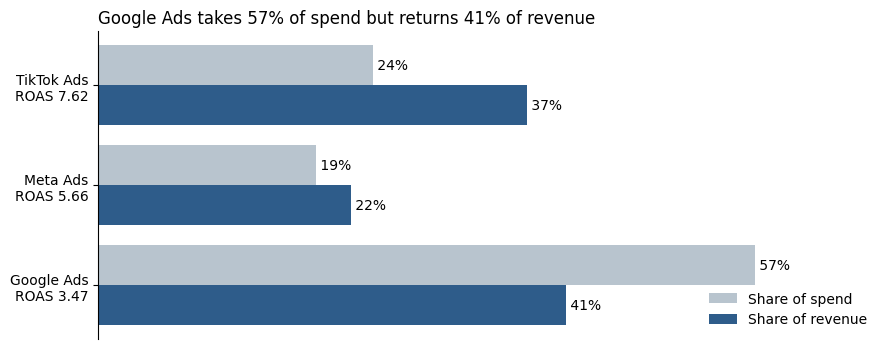

,rows,spend,revenue,conversions,CTR,CPC,CPM,CVR,CPA,ROAS,spend_share,revenue_share
platform,,,,,,,,,,,,
Google Ads,720,"6,349,269","22,033,745","131,098",3.98%,2.16,86.03,4.46%,48.43,3.47,57%,41%
Meta Ads,630,"2,106,062","11,926,046","73,262",2.48%,1.32,32.70,4.59%,28.75,5.66,19%,22%
TikTok Ads,450,"2,653,419","20,223,540","122,452",5.53%,1.02,56.40,4.71%,21.67,7.62,24%,37%


In [6]:
plat = df.groupby('platform').apply(metrics).sort_values('ROAS')
fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(plat))
ax.barh(y + 0.2, plat['spend_share'], 0.4, color=MUTED, label='Share of spend')
ax.barh(y - 0.2, plat['revenue_share'], 0.4, color=ACCENT, label='Share of revenue')
for i, (s, r, roas) in enumerate(zip(plat['spend_share'], plat['revenue_share'], plat['ROAS'])):
    ax.text(s, i + 0.2, f' {s:.0%}', va='center')
    ax.text(r, i - 0.2, f' {r:.0%}', va='center')
ax.set_yticks(y, [f'{p}\nROAS {r:.2f}' for p, r in zip(plat.index, plat['ROAS'])])
ax.set_xticks([]); ax.set_xlim(0, 0.68)
g = plat.loc['Google Ads']
ax.set_title(f"Google Ads takes {g['spend_share']:.0%} of spend but returns {g['revenue_share']:.0%} of revenue", loc='left')
ax.legend(frameon=False, loc='lower right'); ax.spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout(); plt.savefig('images/platform_spend_vs_revenue.png', dpi=150); plt.show()
plat.style.format(fmt)

TikTok has the highest CTR **and** the highest conversion rate, so its lower CPA comes from both steps of the funnel, not just cheaper clicks.

## 5. Platform × campaign type

In [7]:
pt = df.pivot_table(index='platform', columns='campaign_type', values=['revenue', 'ad_spend'], aggfunc='sum')
roas_grid = (pt['revenue'] / pt['ad_spend']).round(2)
roas_grid

campaign_type,Display,Search,Shopping,Video
platform,,,,
Google Ads,3.16,3.92,3.23,3.53
Meta Ads,5.82,5.77,5.54,5.51
TikTok Ads,8.01,8.12,6.85,7.56


The platform gap is larger than any campaign-type gap: the worst TikTok campaign type still beats the best Google campaign type on ROAS. Campaign type matters less than platform in this data.

## 6. Budget reallocation scenario

In [8]:
SHIFT = 0.20  # move 20% of Google Ads spend to TikTok Ads
moved = plat.loc['Google Ads', 'spend'] * SHIFT
delta = moved * (plat.loc['TikTok Ads', 'ROAS'] - plat.loc['Google Ads', 'ROAS'])
print(f"Budget moved:            {moved:,.0f}")
print(f"Revenue change:          +{delta:,.0f} (+{delta / df['revenue'].sum():.1%}) at the same total spend")

Budget moved:            1,269,854
Revenue change:          +5,271,686 (+9.7%) at the same total spend


**Assumption:** each platform keeps its current ROAS as spend changes. Real platforms show diminishing returns (each extra dollar buys less), so this is an upper estimate. The practical next step is to shift a smaller slice, watch ROAS for 2–4 weeks, and keep going only while TikTok's ROAS holds.

## 7. Unprofitable campaign-days

In [9]:
loss = df[df['ROAS'] < 1]
print(f"Campaign-days with ROAS < 1 (revenue below spend): {len(loss)} of {len(df)} ({len(loss)/len(df):.1%})")
print(f"Their spend: {loss['ad_spend'].sum():,.0f} ({loss['ad_spend'].sum()/df['ad_spend'].sum():.1%} of total)")
loss['platform'].value_counts().to_frame('campaign-days with ROAS < 1')

Campaign-days with ROAS < 1 (revenue below spend): 135 of 1800 (7.5%)
Their spend: 1,199,544 (10.8% of total)


,campaign-days with ROAS < 1
platform,
Google Ads,92
Meta Ads,33
TikTok Ads,10


## 8. Weekly monitoring: flag weeks where ROAS drops

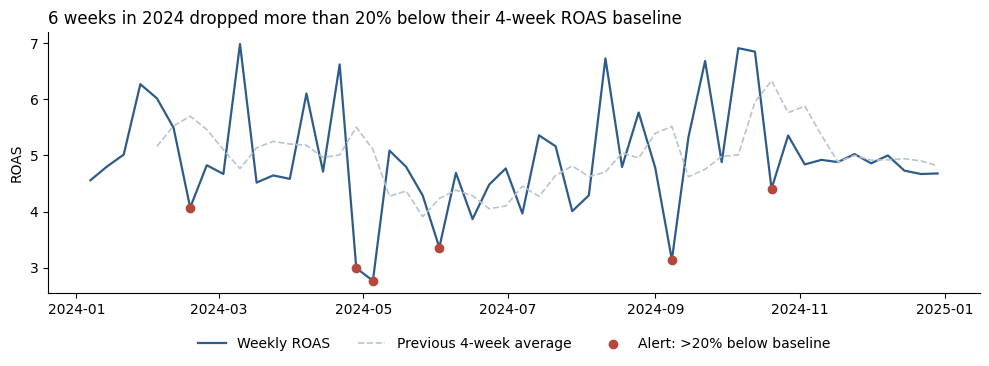

,ad_spend,ROAS,baseline,vs_baseline
date,,,,
2024-02-18 00:00:00,"304,292",4.07,5.70,-29%
2024-04-28 00:00:00,"173,312",3.00,5.50,-46%
2024-05-05 00:00:00,"240,227",2.77,5.11,-46%
2024-06-02 00:00:00,"163,565",3.36,4.23,-21%
2024-09-08 00:00:00,"278,625",3.14,5.51,-43%
2024-10-20 00:00:00,"171,500",4.41,6.33,-30%


In [10]:
weekly = df.set_index('date').resample('W-SUN')[['ad_spend', 'revenue', 'conversions']].sum()
weekly = weekly.iloc[:-1]  # 2024-01-01 is a Monday, so week 1 is complete; drop the partial last week (Dec 30 only)
weekly['ROAS'] = weekly['revenue'] / weekly['ad_spend']
weekly['baseline'] = weekly['ROAS'].shift(1).rolling(4).mean()  # previous 4 weeks
weekly['vs_baseline'] = weekly['ROAS'] / weekly['baseline'] - 1
weekly['alert'] = weekly['vs_baseline'] < -0.20

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(weekly.index, weekly['ROAS'], color=ACCENT, lw=1.6, label='Weekly ROAS')
ax.plot(weekly.index, weekly['baseline'], color=MUTED, lw=1.2, ls='--', label='Previous 4-week average')
a = weekly[weekly['alert']]
ax.scatter(a.index, a['ROAS'], color=BAD, zorder=3, label='Alert: >20% below baseline')
ax.set_title(f"{len(a)} weeks in 2024 dropped more than 20% below their 4-week ROAS baseline", loc='left')
ax.set_ylabel('ROAS'); ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('images/weekly_roas_alerts.png', dpi=150); plt.show()
a[['ad_spend', 'ROAS', 'baseline', 'vs_baseline']].style.format({'ad_spend': '{:,.0f}', 'ROAS': '{:.2f}', 'baseline': '{:.2f}', 'vs_baseline': '{:.0%}'})

In a live account, each alert week would be the starting point for a check: which platform, campaign type or country drove the drop. Because this dataset is simulated, some weekly swings are random noise rather than real events, so the alerts show the **monitoring method**.

## 9. Tableau-ready export

In [11]:
out = df.copy()
out['week_start'] = out['date'] - pd.to_timedelta(out['date'].dt.weekday, unit='D')
out['month'] = out['date'].dt.to_period('M').astype(str)
out.to_csv('ads_performance_for_tableau.csv', index=False)
print(out.shape)

(1800, 16)


## Key findings

1. **Google Ads is over-funded relative to its return.** It takes 57% of spend but returns 41% of revenue, at ROAS 3.47, versus 7.62 for TikTok and 5.66 for Meta.
2. **TikTok wins at both funnel steps:** the highest CTR (5.5%) and the highest conversion rate, giving the lowest CPA.
3. **Platform matters more than campaign type:** every TikTok campaign type beats every Google campaign type on ROAS.
4. **Reallocation scenario:** moving 20% of Google spend to TikTok would add about 5.3M revenue (+9.7%) at the same total spend, assuming ROAS holds. Validate with a gradual shift.
5. **Loss-making spend:** 7.5% of campaign-days had ROAS below 1 (10.8% of spend), and 92 of those 135 were on Google.
6. **Reporting accuracy:** averaging row-level ROAS overstates performance by 32% (6.45 vs. 4.88).

## Limitations
- The dataset is simulated; results demonstrate the method, not real platform performance.
- No budget column, so pacing against plan is not possible; the weekly monitor compares ROAS with its own recent baseline instead.
- Currency is not stated.
- Revenue attribution rules (last click, view-through) are not documented.